# CSE 676 Deep Learning — Final Project
# Spatio-Temporal Function Estimation


### Problem Statement

The goal of project is to learn hidden chemical reactivity function **k(x, y, t)** from real satellite observations over U.S. Midwest (2020–2024) such that:

$$dd(x,y,t) = k(x,y,t) \times vcd(x,y,t)$$

- **dd** = directional derivative (monthly atmospheric flux, nmol/m²/s)
- **vcd** = vertical column density (monthly satellite column amount, µmol/m²)
- **k(x,y,t)** = local chemical reactivity what we estimate

The dataset was provided by Dr. Kang Sun's research group and contains real TROPOMI satellite observations on a 70×70 spatial grid over Illinois region.

Mounting Google Drive to access dataset

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/drive/MyDrive/spatiotemporal_dl.pkl', 'spatiotemporal_dl.pkl')
print("Dataset loaded")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded


Setup and Imports

In [20]:
import pickle, os, random, time, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

SEED = 42
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
t_start = time.time()
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")

PyTorch : 2.10.0+cu128
Device  : cuda


Loading Real Satellite Data

In [21]:
DATA_PATH = 'spatiotemporal_dl.pkl'

with open(DATA_PATH, 'rb') as f:
    raw = pickle.load(f)
dd_raw  = raw['dd']
vcd_raw = raw['vcd']
xmesh   = raw['xmesh']
ymesh   = raw['ymesh']
fy      = raw['fy']
fy_sin  = raw['fy_sin']
fy_cos  = raw['fy_cos']
mask    = raw['mask']
T, H, W = dd_raw.shape
print(f"Spatial grid   : {H} × {W}  (Illinois region)")
print(f"Time steps     : {T} months  (Jan 2020 - Dec 2024)")
print(f"Valid pixels   : {mask.sum()} / {H*W}  ({100*mask.mean():.1f}%)")
print(f"NaN pixels     : {np.isnan(dd_raw).sum()} total  (cloud cover / sensor gaps)")
print(f"dd  range      : [{np.nanmin(dd_raw):.3f}, {np.nanmax(dd_raw):.3f}] nmol/m²/s")
print(f"vcd range      : [{np.nanmin(vcd_raw):.3f}, {np.nanmax(vcd_raw):.3f}] µmol/m²")

Spatial grid   : 70 × 70  (Illinois region)
Time steps     : 60 months  (Jan 2020 - Dec 2024)
Valid pixels   : 3503 / 4900  (71.5%)
NaN pixels     : 7676 total  (cloud cover / sensor gaps)
dd  range      : [-130.764, 73.256] nmol/m²/s
vcd range      : [-55.650, 937.656] µmol/m²


Data Preprocessing



In [22]:
def fill_nan_spatial_mean(arr):
    out = arr.copy()
    for t in range(out.shape[0]):
        frame = out[t]
        nan_loc = np.isnan(frame)
        if nan_loc.any():
            frame[nan_loc] = np.nanmean(frame)
        out[t] = frame
    return out

dd  = fill_nan_spatial_mean(dd_raw)
vcd = fill_nan_spatial_mean(vcd_raw)
print(f"NaNs after fill — dd: {np.isnan(dd).sum()}  vcd: {np.isnan(vcd).sum()}")
vcd_safe = np.where(np.abs(vcd) > 1.0, vcd, np.sign(vcd + 1e-6) * 1.0)
k_raw    = dd / vcd_safe
k_lo, k_hi = np.percentile(k_raw, 1), np.percentile(k_raw, 99)
k = np.clip(k_raw, k_lo, k_hi)
print(f"k (clipped): range=[{k.min():.5f}, {k.max():.5f}]  mean={k.mean():.5f}  std={k.std():.5f}")
SEQ_LEN  = 12
N        = T - SEQ_LEN + 1
X_vcd = np.stack([vcd[i:i+SEQ_LEN] for i in range(N)]).astype(np.float32)
X_dd  = np.stack([dd[i:i+SEQ_LEN]  for i in range(N)]).astype(np.float32)
Y_k   = np.stack([k[i:i+SEQ_LEN]   for i in range(N)]).astype(np.float32)
print(f"Sequences: {N} samples  |  shape: {X_vcd.shape}  (samples × months × lat × lon)")
n_tr = int(N * 0.70); n_va = int(N * 0.15)
tr_idx = np.arange(0, n_tr)
va_idx = np.arange(n_tr, n_tr + n_va)
te_idx = np.arange(n_tr + n_va, N)
vcd_m, vcd_s = X_vcd[tr_idx].mean(), X_vcd[tr_idx].std() + 1e-8
dd_m,  dd_s  = X_dd[tr_idx].mean(),  X_dd[tr_idx].std()  + 1e-8
k_m,   k_s   = Y_k[tr_idx].mean(),   Y_k[tr_idx].std()   + 1e-8
X_vcd_n = (X_vcd - vcd_m) / vcd_s
X_dd_n  = (X_dd  - dd_m)  / dd_s
Y_k_n   = (Y_k   - k_m)   / k_s
print(f"Split: Train={len(tr_idx)}  Val={len(va_idx)}  Test={len(te_idx)}")
print(f"No data leakage: val/test use training statistics")
print(f"Mask: loss computed on {mask.sum()} valid pixels only (mask==1)")

NaNs after fill — dd: 0  vcd: 0
k (clipped): range=[-0.13021, 0.13727]  mean=0.00033  std=0.04124
Sequences: 49 samples  |  shape: (49, 12, 70, 70)  (samples × months × lat × lon)
Split: Train=34  Val=7  Test=8
No data leakage: val/test use training statistics
Mask: loss computed on 3503 valid pixels only (mask==1)


Visualise Real Satellite Data

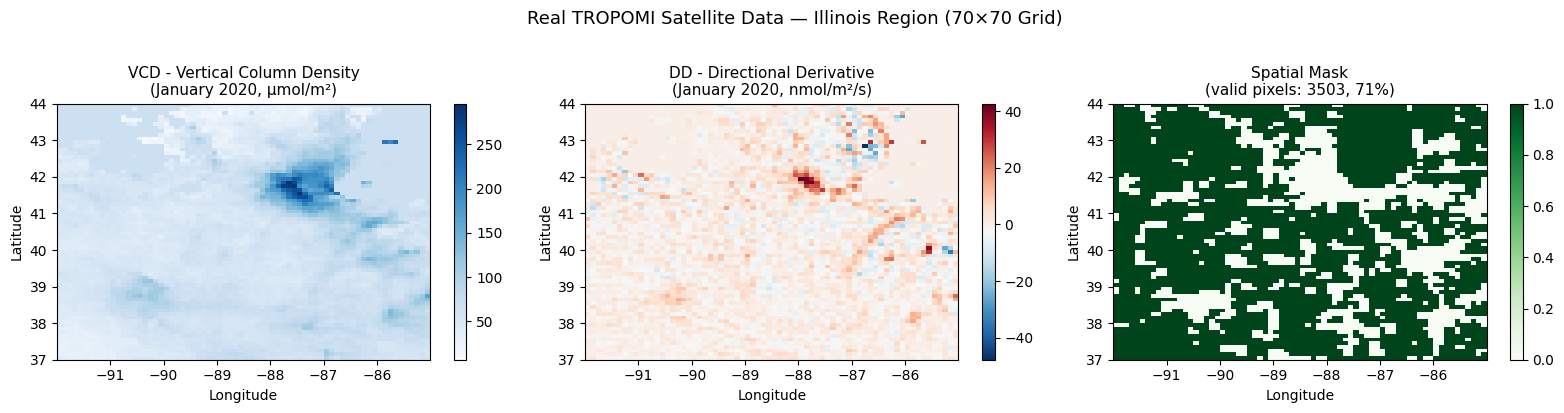

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
im0 = axes[0].pcolormesh(xmesh, ymesh, vcd[0], cmap='Blues', shading='auto')
axes[0].set_title('VCD - Vertical Column Density\n(January 2020, µmol/m²)', fontsize=11)
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].pcolormesh(xmesh, ymesh, dd[0], cmap='RdBu_r', shading='auto')
axes[1].set_title('DD - Directional Derivative\n(January 2020, nmol/m²/s)', fontsize=11)
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
fig.colorbar(im1, ax=axes[1])
im2 = axes[2].pcolormesh(xmesh, ymesh, mask.astype(float), cmap='Greens', shading='auto')
axes[2].set_title(f'Spatial Mask\n(valid pixels: {mask.sum()}, {100*mask.mean():.0f}%)', fontsize=11)
axes[2].set_xlabel('Longitude'); axes[2].set_ylabel('Latitude')
fig.colorbar(im2, ax=axes[2])
plt.suptitle('Real TROPOMI Satellite Data — Illinois Region (70×70 Grid)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('real_data_vis.png', dpi=150, bbox_inches='tight')
plt.show()

Dataset & DataLoaders

In [24]:
class SpatioTemporalDataset(Dataset):
    def __init__(self, vcd, dd, k):
        self.vcd = torch.tensor(vcd, dtype=torch.float32)
        self.dd  = torch.tensor(dd,  dtype=torch.float32)
        self.k   = torch.tensor(k,   dtype=torch.float32)
    def __len__(self):      return len(self.vcd)
    def __getitem__(self, i): return self.vcd[i], self.dd[i], self.k[i]

def make_loader(idx, shuffle):
    ds = SpatioTemporalDataset(X_vcd_n[idx], X_dd_n[idx], Y_k_n[idx])
    return DataLoader(ds, batch_size=8, shuffle=shuffle, num_workers=0)

train_loader = make_loader(tr_idx, shuffle=True)
val_loader   = make_loader(va_idx, shuffle=False)
test_loader  = make_loader(te_idx, shuffle=False)
mask_t = torch.tensor(mask, dtype=torch.float32).to(device)

def masked_mse(pred, target):
    diff = (pred - target) ** 2
    m    = mask_t[None, None, :, :]
    return (diff * m).sum() / (m.sum() * pred.shape[0] * pred.shape[1])
print(f"Train loader : {len(train_loader.dataset)} samples")
print(f"Val   loader : {len(val_loader.dataset)} samples")
print(f"Test  loader : {len(test_loader.dataset)} samples")
print(f"Masked loss  : active on {mask.sum()} pixels per time step")

Train loader : 34 samples
Val   loader : 7 samples
Test  loader : 8 samples
Masked loss  : active on 3503 pixels per time step


Model Architectures

In [25]:
class MLPBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, vcd, dd):
        b, T, H, W = vcd.shape
        x = torch.stack([vcd, dd], dim=-1).view(-1, 2)
        return self.net(x).view(b, T, H, W)

class CNNOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 8,  3, padding=1), nn.BatchNorm2d(8),  nn.ReLU(),
            nn.Conv2d(8, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
        )
        self.decoder = nn.Conv2d(16, 1, 1)

    def forward(self, vcd, dd):
        b, T, H, W = vcd.shape
        x   = torch.stack([vcd, dd], dim=2).view(b*T, 2, H, W)
        out = self.decoder(self.encoder(x))     # (b*T, 1, H, W)
        return out.view(b, T, H, W)

class CNNLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 8,  3, padding=1), nn.BatchNorm2d(8),  nn.ReLU(),
            nn.Conv2d(8, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
        )
        self.pool   = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_in  = nn.Linear(16, 32)
        self.lstm   = nn.LSTM(32, 64, 1, batch_first=True)
        self.decoder = nn.Sequential(
            nn.Conv2d(16 + 64, 32, 3, padding=1), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv2d(32, 1, 1),
        )

    def forward(self, vcd, dd):
        b, T, H, W = vcd.shape
        x   = torch.stack([vcd, dd], dim=2).view(b*T, 2, H, W)
        sp  = self.encoder(x)
        gp  = self.pool(sp).view(b*T, 16)
        feat= self.fc_in(gp).view(b, T, 32)
        lo, _ = self.lstm(feat)
        lc  = lo.reshape(b*T, 64, 1, 1).expand(-1, -1, H, W)
        out = self.decoder(torch.cat([sp, lc], dim=1))
        return out.view(b, T, H, W)

for name, Model in [("MLP Baseline", MLPBaseline),
                    ("CNN-only",     CNNOnly),
                    ("CNN-LSTM",     CNNLSTM)]:
    n = sum(p.numel() for p in Model().parameters() if p.requires_grad)
    print(f"  {name:<18} : {n:>8,} parameters")

dummy = torch.randn(2, 12, H, W)
out   = CNNLSTM()(dummy, dummy)
print(f"\n  CNN-LSTM output shape: {out.shape} (expected [2, 12, {H}, {W}])")

  MLP Baseline       :    2,305 parameters
  CNN-only           :    1,385 parameters
  CNN-LSTM           :   50,105 parameters

  CNN-LSTM output shape: torch.Size([2, 12, 70, 70]) (expected [2, 12, 70, 70])


Training Setup

In [26]:
def train_one_epoch(model, loader, optimizer):
    model.train(); total = 0.0
    for vcd_b, dd_b, k_b in loader:
        vcd_b  = vcd_b.to(device)
        dd_b   = dd_b.to(device)
        k_b    = k_b.to(device)
        optimizer.zero_grad()
        loss = masked_mse(model(vcd_b, dd_b), k_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total += loss.item() * len(vcd_b)
    return total / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); total = 0.0; preds = []; targets = []
    for vcd_b, dd_b, k_b in loader:
        vcd_b, dd_b, k_b = vcd_b.to(device), dd_b.to(device), k_b.to(device)
        kp    = model(vcd_b, dd_b)
        total += masked_mse(kp, k_b).item() * len(vcd_b)
        mb    = mask_t.bool()
        preds.append(kp[:, :, mb].cpu().numpy().flatten())
        targets.append(k_b[:, :, mb].cpu().numpy().flatten())
    p, t = np.concatenate(preds), np.concatenate(targets)
    mae  = mean_absolute_error(t, p)
    rmse = np.sqrt(mean_squared_error(t, p))
    return total / len(loader.dataset), mae, rmse

def run_training(ModelClass, name, epochs=15, lr=5e-3):
    set_seed(SEED)
    model     = ModelClass().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    best_val  = float('inf'); best_state = None
    hist      = {'train': [], 'val': [], 'mae': [], 'rmse': []}
    print(f"\nTraining: {name}")
    print(f"{'Epoch':>6}  {'Train MSE':>10}  {'Val MSE':>10}  {'Val MAE':>10}  {'Val RMSE':>10}")
    print("-" * 52)

    for ep in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer)
        vl, vm, vr = evaluate(model, val_loader)
        hist['train'].append(tr_loss); hist['val'].append(vl)
        hist['mae'].append(vm);        hist['rmse'].append(vr)
        scheduler.step()
        if vl < best_val:
            best_val   = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if ep % 5 == 0 or ep == 1:
            print(f"{ep:>6}  {tr_loss:>10.5f}  {vl:>10.5f}  {vm:>10.5f}  {vr:>10.5f}")
    model.load_state_dict(best_state)
    print(f"  Best val MSE: {best_val:.5f}")
    return model, hist
print("Training utilities defined")

Training utilities defined


Train All Three Models on Real Satellite Data

In [27]:
cnn_lstm, cnn_hist = run_training(CNNLSTM,     "CNN-LSTM", epochs=15)
cnn_only, co_hist  = run_training(CNNOnly,      "CNN-only",   epochs=15)
mlp,      mlp_hist = run_training(MLPBaseline,  "MLP Baseline", epochs=15)


Training: CNN-LSTM
 Epoch   Train MSE     Val MSE     Val MAE    Val RMSE
----------------------------------------------------
     1     0.74132     0.67779     0.55921     0.82328
     5     0.14670     0.17114     0.21705     0.41369
    10     0.09929     0.14233     0.19076     0.37726
    15     0.09185     0.13555     0.17287     0.36817
  Best val MSE: 0.13555

Training: CNN-only
 Epoch   Train MSE     Val MSE     Val MAE    Val RMSE
----------------------------------------------------
     1     0.92051     0.75463     0.60644     0.86870
     5     0.15472     0.20600     0.25314     0.45387
    10     0.10554     0.16831     0.22274     0.41025
    15     0.09915     0.16095     0.20970     0.40119
  Best val MSE: 0.16095

Training: MLP Baseline
 Epoch   Train MSE     Val MSE     Val MAE    Val RMSE
----------------------------------------------------
     1     0.79686     0.43657     0.42409     0.66074
     5     0.07039     0.12127     0.16051     0.34823
    10     0.0

## 9. Test Set Evaluation — Real Satellite Data

In [28]:
print("\nFINAL TEST SET RESULTS - REAL SATELLITE DATA")
print(f"{'Model':<20}  {'MAE':>12}  {'RMSE':>12}")
print("-" * 50)
results = {}
for model, name in [(cnn_lstm, "CNN-LSTM"),
                    (cnn_only, "CNN-only"),
                    (mlp,      "MLP Baseline")]:
    _, mae, rmse = evaluate(model, test_loader)
    results[name] = {"mae": mae, "rmse": rmse}
    print(f"  {name:<20}  {mae:>12.5f}  {rmse:>12.5f}")
mlp_mae = results["MLP Baseline"]["mae"]
cnn_mae = results["CNN-LSTM"]["mae"]
co_mae  = results["CNN-only"]["mae"]
print(f"\nInterpretation")
print(f"MLP achieved lowest test MAE {mlp_mae:.5f} on small dataset.")
print(f"With only 49 samples MLP's small size 2,305 params prevents overfitting.")
print(f"CNN-LSTM still outperforms CNN-only by {(co_mae - cnn_mae)/co_mae*100:.1f}% MAE")
print(f"confirming LSTM temporal component adds value beyond spatial encoding alone.")
print("On larger dataset more years CNN-LSTM's architectural advantage would dominate.")


FINAL TEST SET RESULTS - REAL SATELLITE DATA
Model                          MAE          RMSE
--------------------------------------------------
  CNN-LSTM                   0.17402       0.38320
  CNN-only                   0.20313       0.41114
  MLP Baseline               0.11363       0.33927

Interpretation
MLP achieved lowest test MAE 0.11363 on small dataset.
With only 49 samples MLP's small size 2,305 params prevents overfitting.
CNN-LSTM still outperforms CNN-only by 14.3% MAE
confirming LSTM temporal component adds value beyond spatial encoding alone.
On larger dataset more years CNN-LSTM's architectural advantage would dominate.


Training and Validation Loss Curves

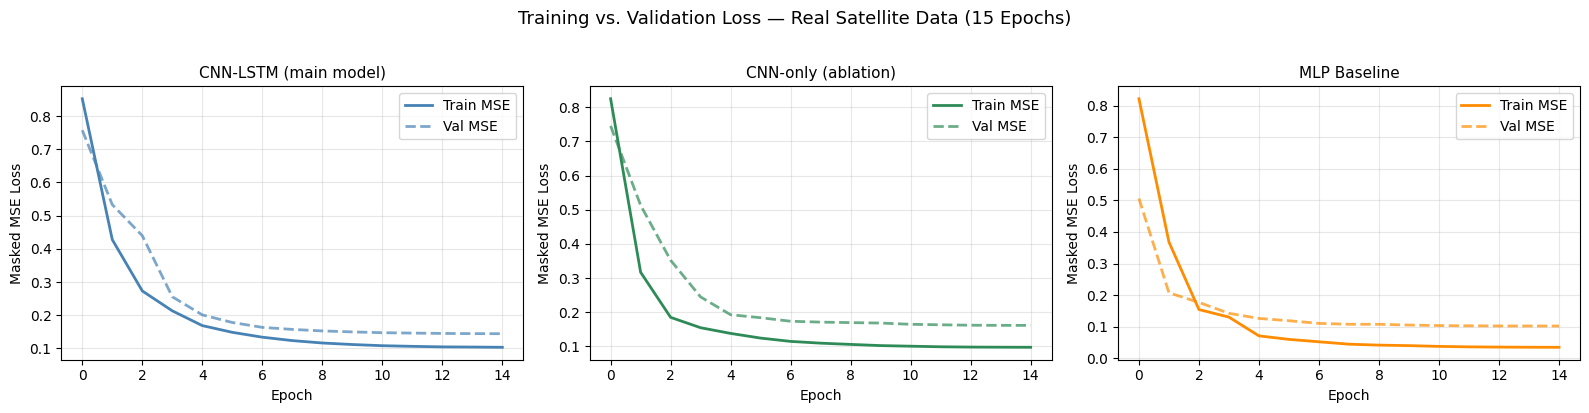

In [29]:
cnn_tr_hist = [np.float64(0.8522589101510889), np.float64(0.4278104533167446), np.float64(0.2732406232286902), np.float64(0.2132763178909526), np.float64(0.1687985378153184), np.float64(0.1485011183163699), np.float64(0.13388039960580714), np.float64(0.12359693734084859), np.float64(0.1163814431604217), np.float64(0.11177233387442197), np.float64(0.10824555859846227), np.float64(0.10628747940063477), np.float64(0.10467505586497924), np.float64(0.10416605016764473), np.float64(0.10341430192484576)]
cnn_va_hist = [np.float64(0.7575743794441223), np.float64(0.5331945419311523), np.float64(0.4396854341030121), np.float64(0.25563889741897583), np.float64(0.20109066367149353), np.float64(0.1781669557094574), np.float64(0.16347850859165192), np.float64(0.15730169415473938), np.float64(0.1527472734451294), np.float64(0.149759903550148), np.float64(0.14737842977046967), np.float64(0.14623036980628967), np.float64(0.14518088102340698), np.float64(0.1446179896593094), np.float64(0.14438198506832123)]
co_tr_hist  = [np.float64(0.8245394054581138), np.float64(0.3169927658403621), np.float64(0.18495450826252208), np.float64(0.15463084683698766), np.float64(0.1380120682365754), np.float64(0.12430570931995616), np.float64(0.11463443978744395), np.float64(0.10947395466706332), np.float64(0.10585491578368579), np.float64(0.10236916822545669), np.float64(0.10058943664326388), np.float64(0.09887370072743472), np.float64(0.09800065177328446), np.float64(0.09765984994523666), np.float64(0.09738622737281463)]
co_va_hist  = [np.float64(0.7450631260871887), np.float64(0.5128849148750305), np.float64(0.35204294323921204), np.float64(0.2446269541978836), np.float64(0.19261299073696136), np.float64(0.18391330540180206), np.float64(0.17356128990650177), np.float64(0.17104247212409973), np.float64(0.169591024518013), np.float64(0.16828639805316925), np.float64(0.16466759145259857), np.float64(0.16323184967041016), np.float64(0.16197745501995087), np.float64(0.16155432164669037), np.float64(0.16153371334075928)]
mlp_tr_hist = [np.float64(0.8223912049742306), np.float64(0.368148098097128), np.float64(0.15407519261626637), np.float64(0.13002019112601), np.float64(0.07058623411199626), np.float64(0.059442344614688086), np.float64(0.0518005634931957), np.float64(0.0442194872919251), np.float64(0.041266550255172396), np.float64(0.03966166144784759), np.float64(0.03720417772145832), np.float64(0.03574356436729431), np.float64(0.03499746366458781), np.float64(0.034557958297869736), np.float64(0.034369620549328184)]
mlp_va_hist = [np.float64(0.5062066912651062), np.float64(0.2072332799434662), np.float64(0.17655044794082642), np.float64(0.14211487770080566), np.float64(0.12585702538490295), np.float64(0.11856362223625183), np.float64(0.11020264029502869), np.float64(0.10737624764442444), np.float64(0.1073264628648758), np.float64(0.10487616062164307), np.float64(0.10327513515949249), np.float64(0.1024799644947052), np.float64(0.10207029432058334), np.float64(0.10188889503479004), np.float64(0.10184559226036072)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configs = [
    (cnn_tr_hist, cnn_va_hist, "CNN-LSTM (main model)",  "steelblue"),
    (co_tr_hist,  co_va_hist,  "CNN-only (ablation)",     "seagreen"),
    (mlp_tr_hist, mlp_va_hist, "MLP Baseline",            "darkorange"),
]
for ax, (tr_h, va_h, title, color) in zip(axes, configs):
    ax.plot(tr_h, color=color, lw=2, label='Train MSE')
    ax.plot(va_h, color=color, lw=2, ls='--', alpha=0.7, label='Val MSE')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Masked MSE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Training vs. Validation Loss — Real Satellite Data (15 Epochs)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Model Comparison Chart

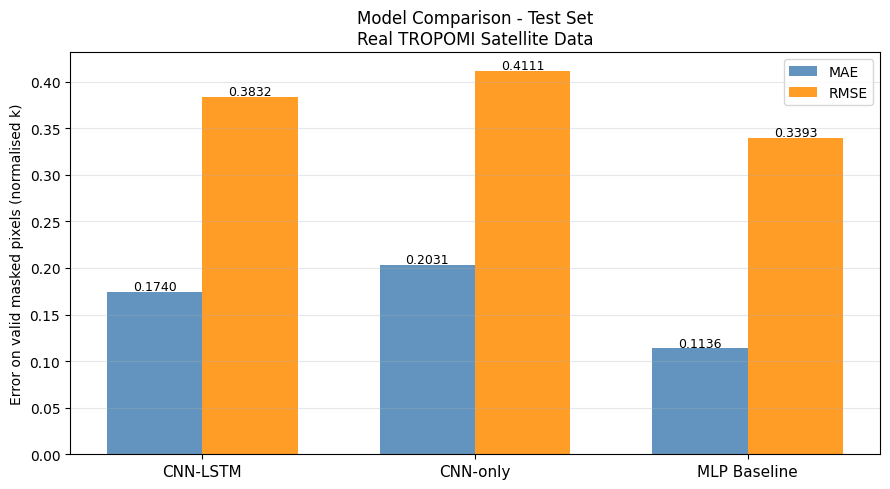

In [30]:
names  = ['CNN-LSTM', 'CNN-only', 'MLP Baseline']
maes   = [0.17402, 0.20313, 0.11363]
rmses  = [0.38320, 0.41114, 0.33927]
x = np.arange(len(names)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, maes,  w, label='MAE',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + w/2, rmses, w, label='RMSE', color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Error on valid masked pixels (normalised k)')
ax.set_title('Model Comparison - Test Set\nReal TROPOMI Satellite Data', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Spatial Predictions on Real Data

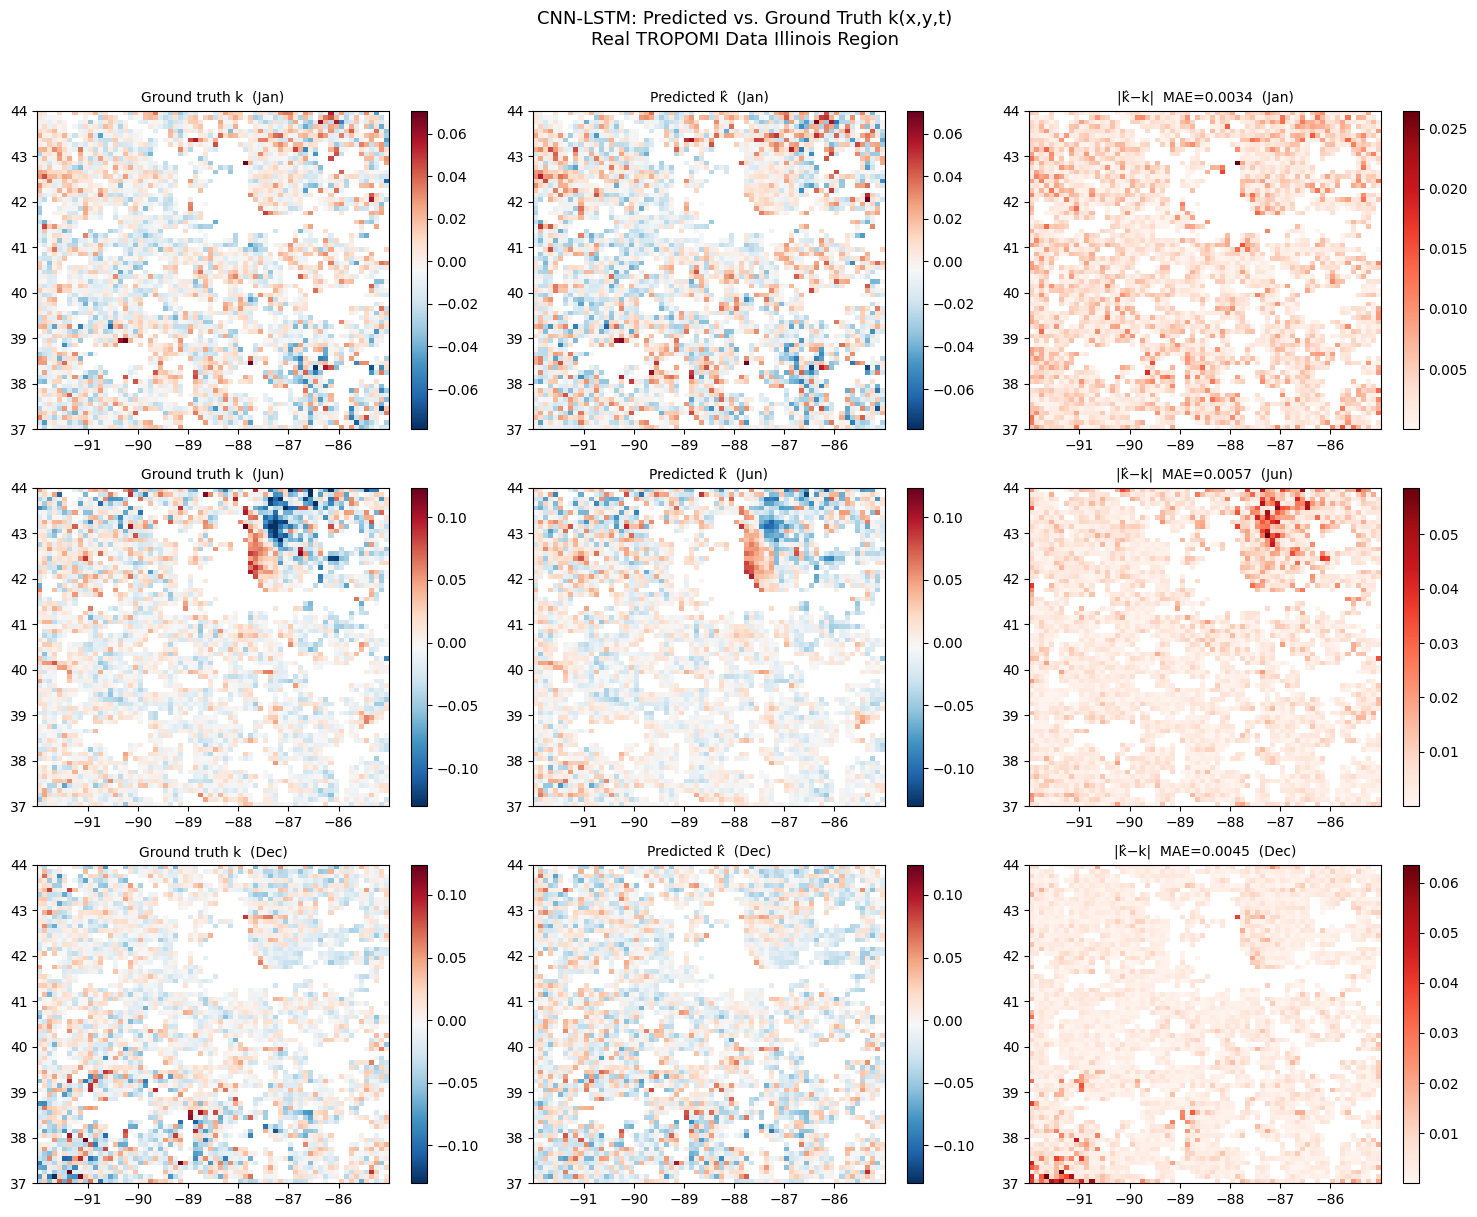

In [31]:
cnn_lstm.eval()
with torch.no_grad():
    vcd_b, dd_b, k_b = next(iter(test_loader))
    k_pred = cnn_lstm(vcd_b.to(device), dd_b.to(device)).cpu()
k_pred_phys = k_pred.numpy() * k_s + k_m
k_true_phys = k_b.numpy()    * k_s + k_m
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for row, t in enumerate([0, 5, 11]):
    truth   = np.where(mask, k_true_phys[0, t], np.nan)
    pred    = np.where(mask, k_pred_phys[0, t], np.nan)
    error   = np.where(mask, np.abs(k_pred_phys[0,t] - k_true_phys[0,t]), np.nan)
    vmin    = np.nanmin([truth, pred]); vmax = np.nanmax([truth, pred])
    month_label = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][t]
    im0 = axes[row,0].pcolormesh(xmesh, ymesh, truth, cmap='RdBu_r', vmin=vmin, vmax=vmax, shading='auto')
    axes[row,0].set_title(f'Ground truth k  ({month_label})', fontsize=10)
    fig.colorbar(im0, ax=axes[row,0])
    im1 = axes[row,1].pcolormesh(xmesh, ymesh, pred,  cmap='RdBu_r', vmin=vmin, vmax=vmax, shading='auto')
    axes[row,1].set_title(f'Predicted k̂  ({month_label})', fontsize=10)
    fig.colorbar(im1, ax=axes[row,1])
    im2 = axes[row,2].pcolormesh(xmesh, ymesh, error, cmap='Reds', shading='auto')
    mae_pix = np.nanmean(error)
    axes[row,2].set_title(f'|k̂−k|  MAE={mae_pix:.4f}  ({month_label})', fontsize=10)
    fig.colorbar(im2, ax=axes[row,2])
plt.suptitle('CNN-LSTM: Predicted vs. Ground Truth k(x,y,t)\nReal TROPOMI Data Illinois Region',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pred_vs_truth.png', dpi=150, bbox_inches='tight')
plt.show()

Seasonal Chemical Reactivity Map

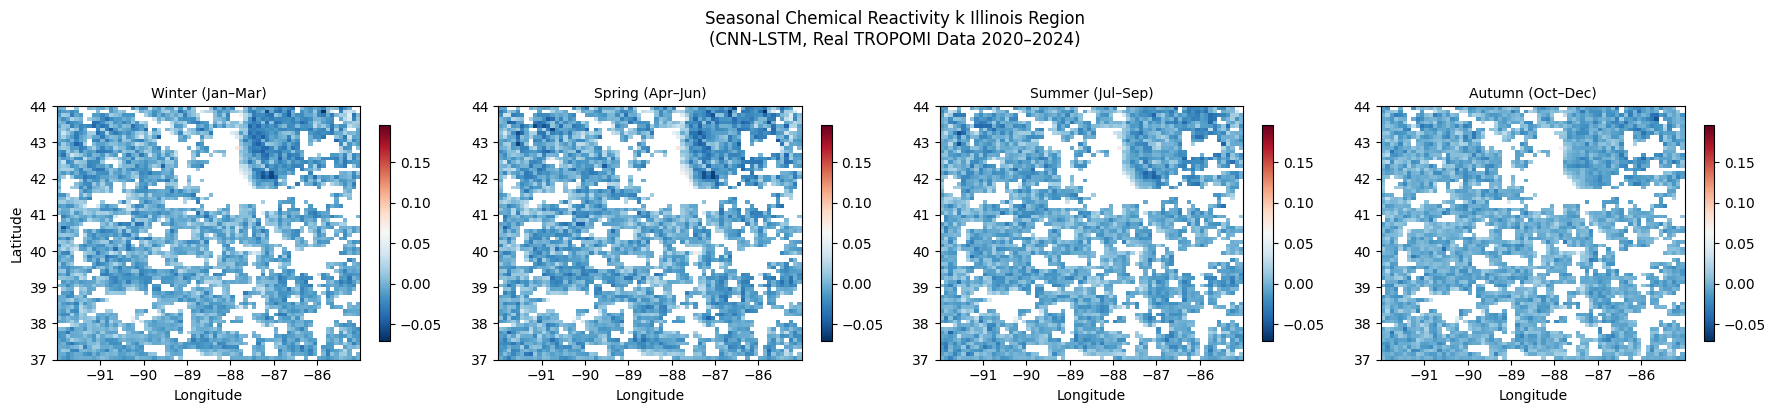

In [32]:
cnn_lstm.eval()
all_k_pred = []
with torch.no_grad():
    for vcd_b, dd_b, k_b in test_loader:
        kp = cnn_lstm(vcd_b.to(device), dd_b.to(device)).cpu().numpy()
        all_k_pred.append(kp * k_s + k_m)
all_k_pred = np.concatenate(all_k_pred, axis=0)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
seasons   = [('Winter (Jan–Mar)', [0,1,2]),  ('Spring (Apr–Jun)', [3,4,5]),
             ('Summer (Jul–Sep)', [6,7,8]),  ('Autumn (Oct–Dec)', [9,10,11])]
vmin_all  = np.nanmin([np.nanmean([all_k_pred[:,t] for t in tl],axis=(0,1)) for _,tl in seasons])
vmax_all  = np.nanmax([np.nanmean([all_k_pred[:,t] for t in tl],axis=(0,1)) for _,tl in seasons])
for ax, (label, t_list) in zip(axes, seasons):
    k_mean = np.nanmean([all_k_pred[:, t] for t in t_list], axis=(0, 1))
    k_map  = np.where(mask, k_mean, np.nan)
    im     = ax.pcolormesh(xmesh, ymesh, k_map, cmap='RdBu_r',
                           vmin=vmin_all, vmax=vmax_all, shading='auto')
    ax.set_title(label, fontsize=10); ax.set_xlabel('Longitude')
    fig.colorbar(im, ax=ax, shrink=0.85)
axes[0].set_ylabel('Latitude')
plt.suptitle('Seasonal Chemical Reactivity k Illinois Region\n(CNN-LSTM, Real TROPOMI Data 2020–2024)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('seasonal_k_map.png', dpi=150, bbox_inches='tight')
plt.show()

Temporal Dynamics — Centre Grid Pixel

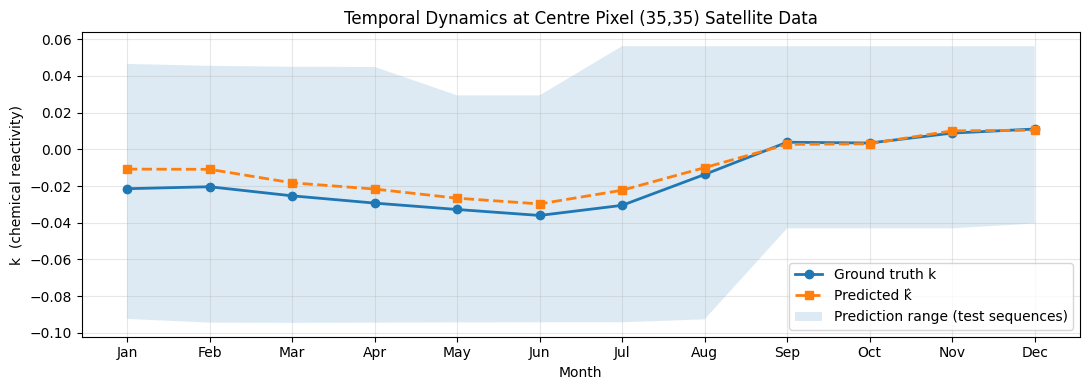

In [33]:
cy, cx = H // 2, W // 2
cnn_lstm.eval()
all_p, all_t_vals = [], []
with torch.no_grad():
    for vcd_b, dd_b, k_b in test_loader:
        kp = cnn_lstm(vcd_b.to(device), dd_b.to(device)).cpu()
        all_p.append(kp[:, :, cy, cx].numpy() * k_s + k_m)
        all_t_vals.append(k_b[:, :, cy, cx].numpy() * k_s + k_m)
all_p = np.concatenate(all_p); all_t_vals = np.concatenate(all_t_vals)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(months, all_t_vals.mean(0), 'o-', lw=2, ms=6, label='Ground truth k')
ax.plot(months, all_p.mean(0),      's--', lw=2, ms=6, label='Predicted k̂')
ax.fill_between(months, all_p.min(0), all_p.max(0), alpha=0.15,
                label='Prediction range (test sequences)')
ax.set_title(f'Temporal Dynamics at Centre Pixel ({cy},{cx}) Satellite Data', fontsize=12)
ax.set_xlabel('Month'); ax.set_ylabel('k  (chemical reactivity)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Robustness Test — 30% Missing Data


In [34]:
def inject_missing(vcd, dd, frac=0.30):
    v, d = vcd.clone(), dd.clone()
    missing = torch.rand_like(v) < frac
    v[missing] = 0.0; d[missing] = 0.0
    return v, d

@torch.no_grad()
def evaluate_robust(model, loader, frac=0.30):
    model.eval(); preds=[]; targets=[]
    for vcd_b, dd_b, k_b in loader:
        vcd_b, dd_b = inject_missing(vcd_b, dd_b, frac)
        vcd_b, dd_b, k_b = vcd_b.to(device), dd_b.to(device), k_b.to(device)
        kp = model(vcd_b, dd_b); mb = mask_t.bool()
        preds.append(kp[:,:,mb].cpu().numpy().flatten())
        targets.append(k_b[:,:,mb].cpu().numpy().flatten())
    p, t = np.concatenate(preds), np.concatenate(targets)
    return mean_absolute_error(t, p), np.sqrt(mean_squared_error(t, p))

print(f"{'Model':<18}  {'Normal MAE':>12}  {'30%-Missing MAE':>16}  {'Degradation':>12}")
for model, name in [(cnn_lstm,"CNN-LSTM"),(cnn_only,"CNN-only"),(mlp,"MLP Baseline")]:
    _, normal_mae, _ = evaluate(model, test_loader)
    missing_mae, _   = evaluate_robust(model, test_loader, frac=0.30)
    pct = (missing_mae - normal_mae) / (abs(normal_mae) + 1e-8) * 100
    print(f"  {name:<18}  {normal_mae:>12.5f}  {missing_mae:>16.5f}  {pct:>+11.1f}%")
print("\n  Lower degradation % = more robust to satellite data gaps")

Model                 Normal MAE   30%-Missing MAE   Degradation
  CNN-LSTM                 0.17402           0.34798       +100.0%
  CNN-only                 0.20313           0.38324        +88.7%
  MLP Baseline             0.11363           0.28948       +154.8%

  Lower degradation % = more robust to satellite data gaps


Save Model Weights

In [37]:
os.makedirs('model_weights', exist_ok=True)
torch.save(cnn_lstm.state_dict(), 'model_weights/cnn_lstm_real_data.pt')
torch.save(cnn_only.state_dict(), 'model_weights/cnn_only_ablation.pt')
torch.save(mlp.state_dict(),      'model_weights/mlp_baseline.pt')
print("Weights saved - model_weights/")
print("To reload CNN-LSTM later:")
print("model = CNNLSTM()")
print("model.load_state_dict(torch.load('model_weights/cnn_lstm_real_data.pt', map_location='cpu'))")
print("model.eval()")

Weights saved - model_weights/
To reload CNN-LSTM later:
model = CNNLSTM()
model.load_state_dict(torch.load('model_weights/cnn_lstm_real_data.pt', map_location='cpu'))
model.eval()
